# STEP 1 · 数据探索
在本 notebook 开头先选择 `CITY`、`CITY_CONFIG` 和 `MODE`。这里看城市数据规模、两种口径的站点保留量、GPS 点数分布、速度分布，以及站点/需求空间分布（带当前城市行政区边界）。


In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'      # 城市配置键；全国城市可改成 'shenzhen' 等
CITY_CONFIG = ''        # 可选：外部 city_configs.json 路径，例如 r'../city_configs.json'
MODE = 'truncated'      # 'truncated' 或 'comprehensive'
NOTEBOOK_SMOKE = False  # True 时减少抽样和候选规模，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
print(f'当前城市：{cso.CITY_NAME} ({cso.CITY}) | 口径：{MODE} | 抽样次数：{DRAWS}')


当前城市：广州 (guangzhou) | 口径：truncated | 抽样次数：40


## 1.1 站点过滤
Truncated 只用轨迹日(含)前已建成的站；Comprehensive 用历史轨迹数据评估全部现存站。


In [3]:
rows=[]
for m in ['truncated','comprehensive']:
    st,s=cso.load_stations(m,return_stats=True)
    rows.append(dict(口径=m, 原始=s['raw'], 保留=s['kept'], 晚于轨迹日=s['future_create'], 零容量=s['zero_cap']))
print(pd.DataFrame(rows).to_string(index=False))


           口径   原始   保留  晚于轨迹日  零容量
    truncated 3191  873   2117  442
comprehensive 3191 2749      0  442


## 1.2 GPS 点数分布 与 速度分布
每辆车的轨迹点数（点数<100 的车会在预处理剔除）；以及分段平均速度分布。


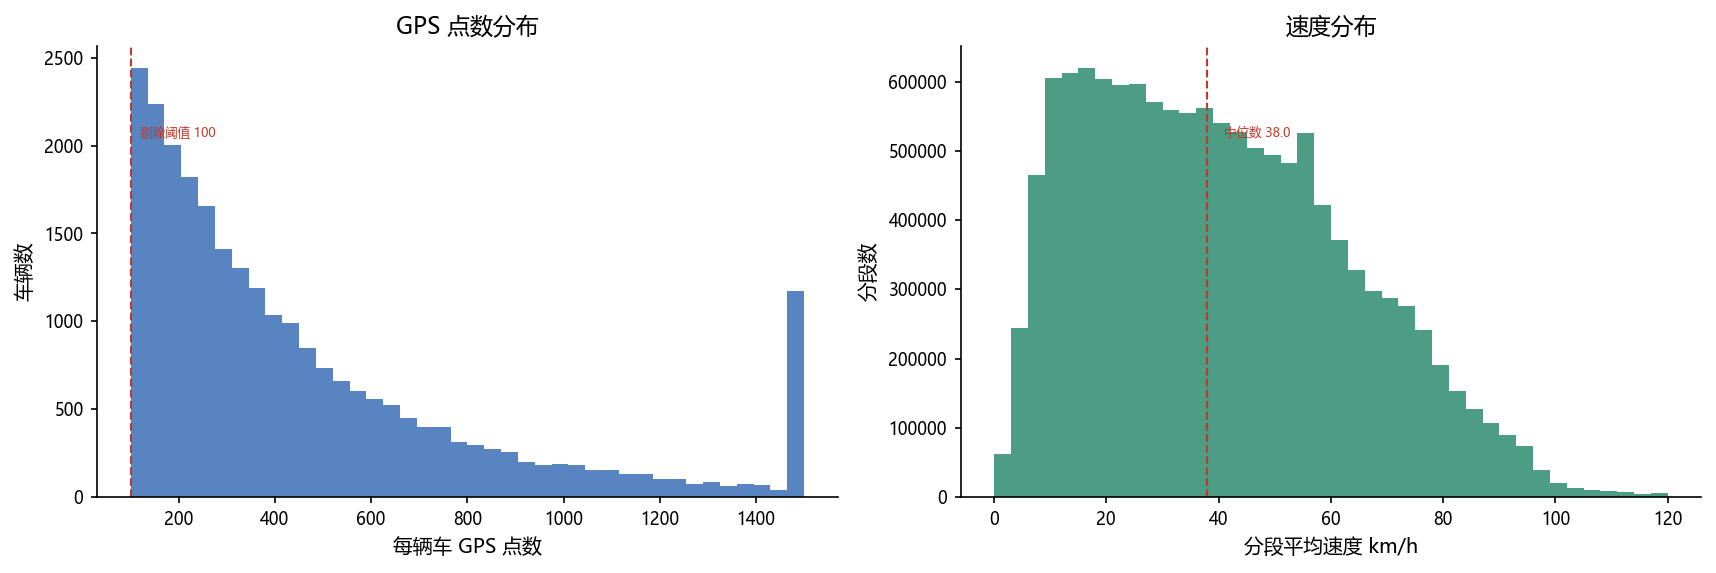

有效轨迹点 12,840,290 | 车辆 25,536 | 速度中位数 38.0 km/h


In [4]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False


z=cso.load_segments()
pts=np.bincount(z['vc']); v=z['v'][z['v']>0]
fig,ax=plt.subplots(1,2,figsize=style.mm(183,62))
ax[0].hist(np.clip(pts,0,1500),bins=40,color=style.C['blue'],alpha=.85)
ax[0].axvline(cso.MIN_TRACK_POINTS,color=style.C['red'],ls='--',lw=1); ax[0].text(cso.MIN_TRACK_POINTS+20,ax[0].get_ylim()[1]*.8,'剔除阈值 %d'%cso.MIN_TRACK_POINTS,color=style.C['red'],fontsize=6)
ax[0].set_xlabel('每辆车 GPS 点数'); ax[0].set_ylabel('车辆数'); ax[0].set_title('GPS 点数分布')
ax[1].hist(np.clip(v,0,120),bins=40,color=style.C['green'],alpha=.85)
ax[1].axvline(np.median(v),color=style.C['red'],ls='--',lw=1); ax[1].text(np.median(v)+3,ax[1].get_ylim()[1]*.8,'中位数 %.1f'%np.median(v),color=style.C['red'],fontsize=6)
ax[1].set_xlabel('分段平均速度 km/h'); ax[1].set_ylabel('分段数'); ax[1].set_title('速度分布')
plt.tight_layout(); plt.show()
print(f'有效轨迹点 {len(z["vc"]):,} | 车辆 {int(z["n_veh"]):,} | 速度中位数 {np.median(v):.1f} km/h')


## 1.3 站点与 GPS 轨迹空间分布

这里看的是当前城市 bbox 内的原始 GPS 轨迹点和充电站空间覆盖关系，用来先判断轨迹覆盖范围、站点是否落在主要活动区附近。


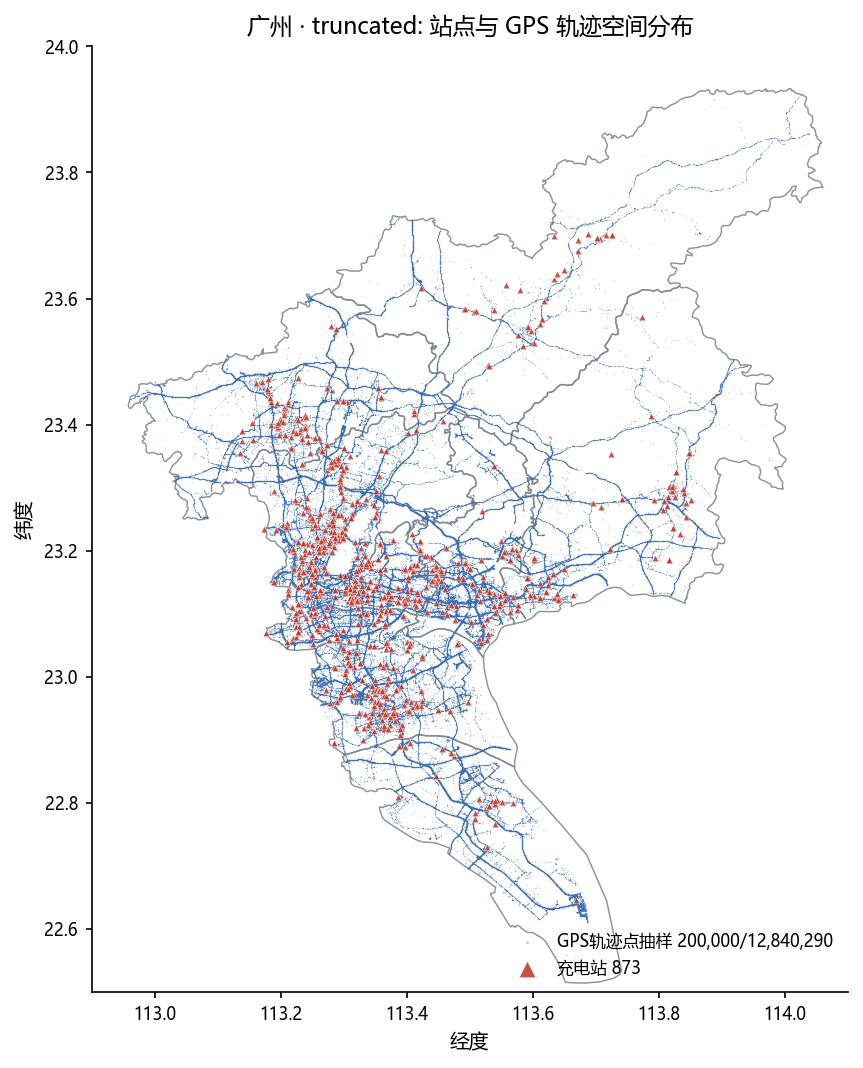

In [10]:
st = cso.load_stations(MODE)
z = cso.load_segments()
lon, lat = z['lon'], z['lat']
max_points = min(30000, len(lon)) if NOTEBOOK_SMOKE else min(200000, len(lon))
rng = np.random.default_rng(cso.SEED)
if len(lon) > max_points:
    idx = rng.choice(len(lon), size=max_points, replace=False)
else:
    idx = np.arange(len(lon))
fig, ax = plt.subplots(figsize=style.mm(130, 130))
style.draw_admin(ax, cache_dir=cso.DATA, adcode=cso.CITY_ADMIN_ADCODE, color='#7E8795', lw=0.7)
ax.scatter(lon[idx], lat[idx], s=0.35, c=style.C['blue'], alpha=0.30, linewidths=0,
           rasterized=True, zorder=2, label=f'GPS轨迹点抽样 {len(idx):,}/{len(lon):,}')
ax.scatter(st['lon'], st['lat'], s=10, c=style.C['red'], marker='^', alpha=0.88,
           edgecolor='white', linewidths=0.25, zorder=4, label=f'充电站 {len(st):,}')
ax.set_xlim(cso.BBOX['lon_min'], cso.BBOX['lon_max'])
ax.set_ylim(cso.BBOX['lat_min'], cso.BBOX['lat_max'])
ax.legend(loc='lower right', markerscale=2.5)
ax.set_title(f'{cso.CITY_NAME} · {MODE}: 站点与 GPS 轨迹空间分布')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('经度')
ax.set_ylabel('纬度')
plt.show()
